In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyblock.blocking

from jaqmc.utils.config import ConfigManager

In [2]:
digest = dict(
    np.load(
        "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/evaluation_digest.npz"
    )
)

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

Digest contents:
  energy:ecp: 7.508995+0.001014j
  energy:ecp_var: 94.276382+1.405906j
  energy:kinetic: 19.465214-0.001000j
  energy:kinetic_var: 58.032181+1.697878j
  energy:potential: -74.206558
  energy:potential_var: 106.394569
  total_energy: -47.232353+0.000014j
  total_energy_real: -47.232349
  total_energy_real_var: 0.431116


In [3]:
with h5py.File(
    "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/evaluation_stats.h5",
    "r",
) as f:
    print("Per-step statistics:")
    for key in sorted(f.keys()):
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")

    total_energy = f["total_energy"][:]

Per-step statistics:
  energy:ecp: shape=(100,), dtype=complex64
  energy:ecp_var: shape=(100,), dtype=complex64
  energy:kinetic: shape=(100,), dtype=complex64
  energy:kinetic_var: shape=(100,), dtype=complex64
  energy:potential: shape=(100,), dtype=float32
  energy:potential_var: shape=(100,), dtype=float32
  total_energy: shape=(100,), dtype=complex64
  total_energy_real: shape=(100,), dtype=float32
  total_energy_real_var: shape=(100,), dtype=float32


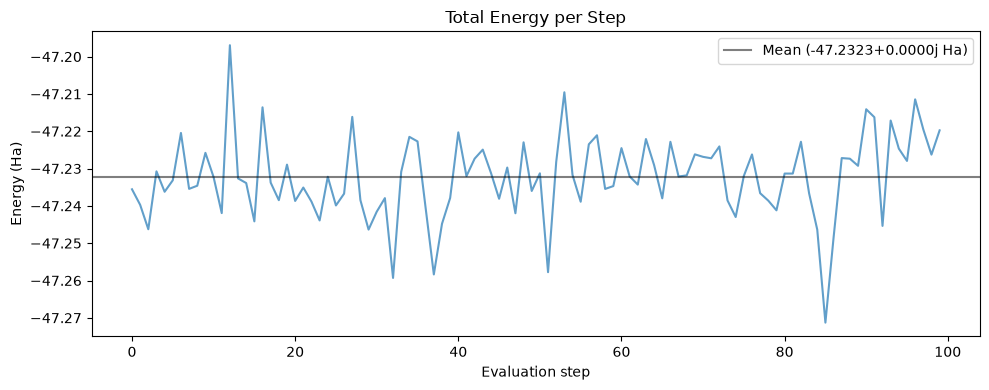

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(total_energy, alpha=0.7)
ax.axhline(
    y=np.mean(total_energy),
    color="k",
    linestyle="-",
    alpha=0.5,
    label=f"Mean ({np.mean(total_energy):.4f} Ha)",
)
ax.set_xlabel("Evaluation step")
ax.set_ylabel("Energy (Ha)")
ax.set_title("Total Energy per Step")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
reblock_data = pyblock.blocking.reblock(total_energy)
opt = pyblock.blocking.find_optimal_block(len(total_energy), reblock_data)

if opt:
    optimal = reblock_data[opt[0]]
    print(f"Optimal block level: {opt[0]}")
    print(f"  Block size:     2^{opt[0]} = {2 ** opt[0]} steps")
    print(f"  Mean energy:    {optimal.mean:.6f} Ha")
    print(f"  Std error:      {optimal.std_err:.6f} Ha")
    print(f"  Std error err:  {optimal.std_err_err:.6f} Ha")
    print(f"\n  Energy: {optimal.mean:.6f} ± {optimal.std_err:.6f} Ha")
else:
    print("Could not find optimal block (too few data points).")
    print("Using the largest available block level instead.")
    largest = reblock_data[-1]
    print(f"\n  Energy: {largest.mean:.6f} ± {largest.std_err:.6f} Ha")

Optimal block level: 3
  Block size:     2^3 = 8 steps
  Mean energy:    -47.232891+0.000196j Ha
  Std error:      0.001346+0.000000j Ha
  Std error err:  0.000287+0.000000j Ha

  Energy: -47.232891+0.000196j ± 0.001346+0.000000j Ha


/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/numpy/ma/core.py:3452: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


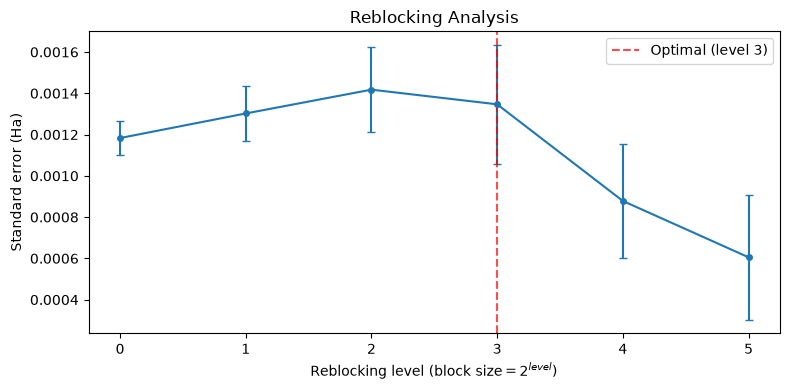

In [7]:
block_levels = np.arange(len(reblock_data))
std_errs = np.array([r.std_err for r in reblock_data])
std_err_errs = np.array([r.std_err_err for r in reblock_data])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    block_levels, std_errs, yerr=std_err_errs, marker="o", markersize=4, capsize=3
)
if opt:
    ax.axvline(
        x=opt[0],
        color="r",
        linestyle="--",
        alpha=0.7,
        label=f"Optimal (level {opt[0]})",
    )
    ax.legend()
ax.set_xlabel("Reblocking level ($\\mathrm{block\\ size} = 2^{level}$)")
ax.set_ylabel("Standard error (Ha)")
ax.set_title("Reblocking Analysis")
plt.tight_layout()
plt.show()

# With density estimator in YAML

In [4]:
digest = dict(
    np.load(
        "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6_density/evaluation_digest.npz"
    )
)

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

Digest contents:
  density: shape=(100,)
  density:n_steps: 100.000000
  energy:ecp: 7.516607+0.000324j
  energy:ecp_var: 94.439819+0.223988j
  energy:kinetic: 19.505646-0.000209j
  energy:kinetic_var: 59.136673+0.307097j
  energy:potential: -74.258232
  energy:potential_var: 106.318031
  total_energy: -47.235977+0.000115j
  total_energy_real: -47.235970
  total_energy_real_var: 0.404563


In [5]:
with h5py.File(
    "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6_density/evaluation_stats.h5",
    "r",
) as f:
    print("Per-step statistics:")
    for key in sorted(f.keys()):
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")

    total_energy = f["total_energy"][:]

Per-step statistics:
  energy:ecp: shape=(100,), dtype=complex64
  energy:ecp_var: shape=(100,), dtype=complex64
  energy:kinetic: shape=(100,), dtype=complex64
  energy:kinetic_var: shape=(100,), dtype=complex64
  energy:potential: shape=(100,), dtype=float32
  energy:potential_var: shape=(100,), dtype=float32
  total_energy: shape=(100,), dtype=complex64
  total_energy_real: shape=(100,), dtype=float32
  total_energy_real_var: shape=(100,), dtype=float32


In [6]:
density_raw = digest["density"]
n_steps = digest["density:n_steps"]
print(f"Raw histogram shape: {density_raw.shape}")
print(f"Total counts:        {density_raw.sum():.0f}")
print(f"Evaluation steps:    {n_steps}")

Raw histogram shape: (100,)
Total counts:        4915200
Evaluation steps:    100


In [7]:
density_raw

array([149701., 148691., 146575., 144715., 142578., 140038., 136596.,
       129993., 121142., 110653.,  98978.,  87733.,  76095.,  65434.,
        56464.,  48273.,  41637.,  35639.,  30599.,  26774.,  23358.,
        20710.,  18700.,  17528.,  16056.,  15136.,  14445.,  13786.,
        13632.,  13379.,  13218.,  13114.,  13374.,  13486.,  14099.,
        14298.,  14841.,  15493.,  16223.,  16956.,  17539.,  18302.,
        18850.,  20062.,  20752.,  21565.,  22442.,  23102.,  23846.,
        23818.,  24242.,  24005.,  23323.,  22315.,  21443.,  20834.,
        20060.,  18855.,  18017.,  17411.,  16668.,  15810.,  15462.,
        15136.,  14454.,  14073.,  13980.,  13703.,  13554.,  13244.,
        13280.,  13553.,  13985.,  14352.,  15278.,  16141.,  17276.,
        18879.,  20396.,  23021.,  26369.,  30183.,  35041.,  40724.,
        47690.,  55915.,  65516.,  75814.,  87027.,  98465., 109990.,
       120467., 129497., 136585., 140169., 143560., 144640., 146708.,
       148447., 1492

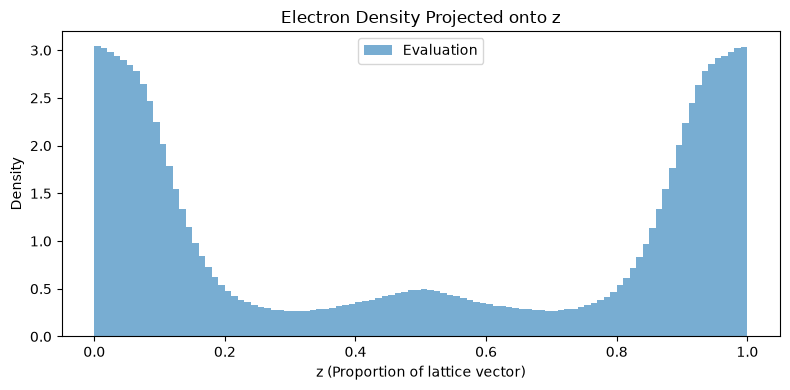

In [8]:
# From https://jaqmc.readthedocs.io/latest/systems/solid/eval.html#solid-estimators the histogram is from 0 to 1?

# atoms:
# - symbol: Sc
#   coords: [0.0, 0.0, 0.0]
#   charge: 11.0
# - symbol: H
#   coords: [3.78, 0.0, 0.0]
#   charge: 1.0

z_min, z_max, n_bins = 0, 1, len(density_raw)
bin_width = (z_max - z_min) / n_bins
bin_centers = np.linspace(z_min + bin_width / 2, z_max - bin_width / 2, n_bins)

density = density_raw / (density_raw.sum() * bin_width)


z_fine = np.linspace(z_min, z_max, 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_centers, density, width=bin_width, alpha=0.6, label="Evaluation")
ax.set_xlabel("z (Proportion of lattice vector)")
ax.set_ylabel("Density")
ax.set_title("Electron Density Projected onto z")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Just to check normalization...
integral = np.sum(density * bin_width)
print(integral)

0.99999994


# Plot wavefunctions

In [9]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import time
from dataclasses import replace

import jax
import yaml

from jaqmc.app.solid.workflow import SolidEvalWorkflow
from jaqmc.workflow.base import init_batched_data

# ==========================================
# 1. Setup Paths & Load Config
# ==========================================
base_dir = Path("/rds/user/jc2405/hpc-work/JaQMC/jaqmc")
yaml_path = base_dir / "configs/sc_h_chain.yml"
checkpoint_dir = base_dir / "runs/sc_h_chain_3.78_spin_6_6"
target_ckpt_file = checkpoint_dir / "train_ckpt_009999.npz"

with open(yaml_path, encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)

# Inject overrides
raw_cfg["workflow"] = raw_cfg.get("workflow", {})
raw_cfg["workflow"]["source_path"] = str(target_ckpt_file)
raw_cfg["workflow"]["save_path"] = str(checkpoint_dir / "eval_results")
raw_cfg["estimators"] = {"enabled": {"density": True}}

# ==========================================
# 2. Define the Workflow
# ==========================================
cfg = ConfigManager(raw_cfg)
eval_workflow = SolidEvalWorkflow(cfg)

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [10]:
from pathlib import Path

import numpy as np

# 1. Define a cache file path inside your run directory
klist_cache_file = checkpoint_dir / "cached_klist.npy"

# 2. Check if we already did the 15-minute math
if klist_cache_file.exists():
    print("Loading cached k-points from disk...")

    # Load the array (allow_pickle=True handles lists of arrays)
    cached_klist = np.load(klist_cache_file, allow_pickle=True)

    # Inject it directly into the wavefunction
    eval_workflow.wf.klist = cached_klist
    print("Run SCF: Skipped (Loaded from cache!)")

else:
    print("Running SCF... ")

    # Run the expensive calculation
    eval_workflow.scf.run()

    # Extract the results
    klist = eval_workflow.scf.get_orbital_kpoints()
    eval_workflow.wf.klist = klist

    # Save the array to disk for all future runs
    np.save(klist_cache_file, klist)
    print(f"Run SCF: Complete. Data cached permanently to {klist_cache_file.name}")

Loading cached k-points from disk...
Run SCF: Skipped (Loaded from cache!)


In [11]:
# 2. Setup Random Keys
seed = int(time.time())
rngs = jax.random.PRNGKey(seed)
rngs, data_rngs = jax.random.split(rngs)

# 3. Initialize blank walkers based on your config
batched_data = init_batched_data(
    eval_workflow.data_init, eval_workflow.config.batch_size, data_rngs
)

# 4. Create an empty template state
rngs, sub_rngs = jax.random.split(rngs)
state = eval_workflow.evaluation_stage.create_state(sub_rngs, batched_data=batched_data)

# 5. Create the wrapper dictionary to tell the checkpoint manager what to load
wrapper = {
    "params": state.params,
    "batched_data": state.batched_data,
    "sampler_state": state.sampler_state,
}

# 6. Restore the checkpoint state (Call it on the evaluation_stage!)
target_ckpt_file = checkpoint_dir / "train_ckpt_009999.npz"
restored = eval_workflow.evaluation_stage.restore_checkpoint(
    target_ckpt_file, wrapper, prefix=""
)

# 7. Replace the empty state with the restored values
state = replace(
    state,
    params=restored["params"],
    batched_data=restored["batched_data"],
    sampler_state=restored["sampler_state"],
)

params = state.params
batched_data = state.batched_data
wf = eval_workflow.wf

print(
    f"Successfully loaded {batched_data.batch_size} walkers from {target_ckpt_file.name}!"
)

Successfully loaded 4096 walkers from train_ckpt_009999.npz!


In [12]:
params = state.params
batched_data = state.batched_data

print("Loaded state contents:")
print(
    f"  - params: {type(params).__name__} with {sum(p.size for p in jax.tree.leaves(params)):,} parameters"
)
print(f"  - batched_data: {batched_data.batch_size} walkers")
print(f"  - electron positions shape: {batched_data.data.electrons.shape}")

Loaded state contents:
  - params: dict with 848,608 parameters
  - batched_data: 4096 walkers
  - electron positions shape: (4096, 12, 3)


In [13]:
state

SamplingState(params={'params': {'backbone_layer': {'Dense_0': {'bias': Array([ 0.28582448,  0.001586  , -0.07554792,  0.07949714, -0.02968727,
       -0.35707837,  0.24581407, -0.1467102 , -0.11049795, -0.4842068 ,
       -0.01624395,  0.07829133, -0.08746917, -0.18131939,  0.20922999,
        0.1730556 , -0.39233747, -0.03472026, -0.00614556,  0.05230239,
        0.31925097, -0.02723791, -0.22037293,  0.03334649,  0.10746539,
       -0.25974795,  0.06197038, -0.07829171,  0.08881076, -0.2213666 ,
       -0.0303496 , -0.1266822 , -0.05346533,  0.16268535,  0.21437857,
        0.01628108, -0.01782516, -0.07101116, -0.28766984, -0.0305888 ,
       -0.00704773,  0.07653099, -0.02180903,  0.01687833,  0.11217096,
       -0.07343856,  0.04054211, -0.01311943, -0.03432364,  0.10297254,
       -0.06327046,  0.16234544, -0.07469387, -0.0125561 , -0.00565326,
       -0.12415606, -0.10349123,  0.01231119,  0.27813774, -0.16668868,
        0.00059413, -0.11825006, -0.09809532, -0.05828313, -0.04

In [14]:
batched_data

BatchedData(data=SolidData(electrons=Array([[[5.3461170e-01, 9.9896217e+01, 1.1347431e+00],
        [6.8898063e+00, 9.9337921e+01, 9.9319046e+01],
        [5.9572825e+00, 9.9958519e+01, 9.9740952e+01],
        ...,
        [2.0153221e-02, 9.2988217e-01, 9.9470367e+01],
        [3.9698405e+00, 3.9715353e-01, 4.4938242e-01],
        [9.9582106e-01, 9.8114761e+01, 9.9917725e+01]],

       [[5.9397593e-02, 9.9855011e+01, 9.9005440e+01],
        [7.2309107e-01, 3.2211015e-01, 1.9480497e-02],
        [6.8040128e+00, 7.8941834e-01, 9.9097565e+01],
        ...,
        [7.1946244e+00, 9.9430397e+01, 9.8591774e+01],
        [8.7759668e-01, 7.7665681e-01, 7.2046518e-02],
        [1.0474963e-01, 2.4456662e-01, 4.1746454e+00]],

       [[7.4897451e+00, 9.9217834e+01, 4.2080879e-02],
        [1.1539785e+00, 9.9819839e+01, 9.9178459e+01],
        [7.4490623e+00, 9.9912056e+01, 9.9521843e+01],
        ...,
        [6.4625964e+00, 9.9320221e+01, 2.8662619e-01],
        [7.4673784e-01, 9.9050888e+01, 9

In [15]:
print(batched_data.data.electrons.shape)
print(batched_data.batch_size)

(4096, 12, 3)
4096


In [16]:
from jax import numpy as jnp

from jaqmc.estimator import EstimatorPipeline
from jaqmc.estimator.kinetic import EuclideanKinetic
from jaqmc.utils import parallel_jax
from jaqmc.utils.config import ConfigManager

P = jax.sharding.PartitionSpec

evaluate_wf = parallel_jax.jit_sharded(
    lambda p, bd: jax.vmap(wf.apply, in_axes=(None, bd.vmap_axis))(p, bd.data),
    in_specs=(P(), batched_data.partition_spec),
    out_specs=parallel_jax.DATA_PARTITION,
)
wf_output = evaluate_wf(params, batched_data)

print("Wavefunction output keys:", list(wf_output.keys()))
print(f"\nlog(ψ) shape: {wf_output['logpsi'].shape}")
print("log(ψ) statistics:")
print(f"  mean: {jnp.mean(wf_output['logpsi']):.4f}")
print(f"  std:  {jnp.std(wf_output['logpsi']):.4f}")

Wavefunction output keys: ['abs_logdets', 'logpsi', 'sign_logdets']

log(ψ) shape: (4096,)
log(ψ) statistics:
  mean: -14.8590-0.9168j
  std:  2.7180


In [17]:
import jax.numpy as jnp

# Extract the electron coordinates array from the state
electrons = state.batched_data.data.electrons

# 1. Output the absolute global range (across all walkers, electrons, and x/y/z axes)
global_min = jnp.min(electrons)
global_max = jnp.max(electrons)
print(f"Global coordinate range: [{global_min:.4f}, {global_max:.4f}]")

# 2. Output the range specific to each spatial axis (X, Y, Z)
# By reducing across axis 0 (walkers) and axis 1 (electrons), we keep axis 2 (spatial dims)
axis_min = jnp.min(electrons, axis=(0, 1))
axis_max = jnp.max(electrons, axis=(0, 1))

print(f"X-axis range: [{axis_min[0]:.4f}, {axis_max[0]:.4f}]")
print(f"Y-axis range: [{axis_min[1]:.4f}, {axis_max[1]:.4f}]")
print(f"Z-axis range: [{axis_min[2]:.4f}, {axis_max[2]:.4f}]")

Global coordinate range: [0.0000, 99.9999]
X-axis range: [0.0000, 7.5600]
Y-axis range: [0.0000, 99.9999]
Z-axis range: [0.0000, 99.9998]


In [18]:
import dataclasses

# Extract a single walker by indexing dim 0 of each batched field
single_data = dataclasses.replace(
    batched_data.data,
    **{k: batched_data.data[k][0] for k in batched_data.fields_with_batch},
)
single_output = wf.apply(params, single_data)
single_output

{'logpsi': Array(-13.6403675+0.6220687j, dtype=complex64),
 'sign_logdets': Array([ 0.24683899+0.96905655j, -0.1006426 +0.9949229j ,
         0.8128262 +0.5825063j ,  0.99323297+0.11613918j,
        -0.2080951 -0.97810847j,  0.973398  +0.2291222j ,
        -0.03558836-0.9993664j , -0.7413863 +0.67107904j,
        -0.94458294-0.32827386j, -0.32160538+0.94687355j,
         0.852529  +0.5226792j ,  0.10136446-0.99484926j,
        -0.8335619 -0.5524261j , -0.9929608 -0.11844201j,
         0.9984206 +0.05618216j,  0.9320772 -0.36225918j], dtype=complex64),
 'abs_logdets': Array([-25.442116, -24.37291 , -13.640346, -25.570713, -23.434683,
        -24.718605, -23.52034 , -22.32079 , -24.63039 , -22.148504,
        -24.391092, -24.62672 , -25.5879  , -23.835407, -25.055708,
        -23.677473], dtype=float32)}

In [9]:
print("Single walker evaluation:")
print(f"  log(ψ) = {single_output['logpsi']:.6f}")

Single walker evaluation:
  log(ψ) = -13.640368+0.622069j


In [19]:
import jax

from jaqmc.app.solid.hamiltonian import PotentialEnergy

# 1. Extract the computed supercell lattice directly from the workflow's wavefunction
supercell_lattice = eval_workflow.wf.simulation_lattice

# 2. Initialize the Solid estimators
kinetic_est = EuclideanKinetic(f_log_psi=wf.logpsi, data_field="electrons")
potential_est = PotentialEnergy(supercell_lattice=supercell_lattice)

estimators = {
    "kinetic": kinetic_est,
    "potential": potential_est,
}

# 3. Build and initialize the pipeline
pipeline = EstimatorPipeline(estimators)
estimator_state = pipeline.init(batched_data, jax.random.PRNGKey(0))

print("Pipeline initialized successfully!")

Pipeline initialized successfully!


In [20]:
raw_cfg

{'system': {'lattice_vectors': [[7.56, 0.0, 0.0],
   [0.0, 100.0, 0.0],
   [0.0, 0.0, 100.0]],
  'atoms': [{'symbol': 'Sc', 'coords': [0.0, 0.0, 0.0], 'charge': 11.0},
   {'symbol': 'H', 'coords': [3.78, 0.0, 0.0], 'charge': 1.0}],
  'electron_spins': [6, 6],
  'basis': {'Sc': 'ccecpccpvdz', 'H': 'cc-pvdz'},
  'ecp': {'Sc': 'ccecp'}},
 'estimators': {'enabled': {'density': True}},
 'workflow': {'source_path': '/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/train_ckpt_009999.npz',
  'save_path': '/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/eval_results'}}

In [12]:
# P = jax.sharding.PartitionSpec

# evaluate = parallel_jax.jit_sharded(
#     pipeline.evaluate,
#     in_specs=(
#         P(),                          # params: replicated
#         batched_data.partition_spec,  # batched_data: batch dim sharded
#         P(),                          # estimator_state: no array leaves
#         P(),                          # rngs: replicated
#     ),
#     out_specs=(
#         P(),                          # step_stats: reduced scalars
#         P(),                          # estimator_state: no array leaves
#     ),
# )

# mean_stats, estimator_state = evaluate(
#     params, batched_data, estimator_state, jax.random.PRNGKey(1)
# )

# # finalize_stats() expects a leading step dimension — add one for single-step use
# batched_mean_stats = jax.tree.map(lambda x: x[None], mean_stats)
# final_stats = pipeline.finalize_stats(batched_mean_stats, estimator_state)

# print(f"Computed observables (from {batched_data.batch_size} walkers):")
# print(f"  Kinetic energy:   {final_stats['energy:kinetic']:.6f} Ha")
# print(f"  Potential energy: {final_stats['energy:potential']:.6f} Ha")
# total_energy = final_stats['energy:kinetic'] + final_stats['energy:potential']
# print(f"  Total energy:     {total_energy:.6f} Ha")

In [15]:
# Ran the above code on GPU, outputs are

# Loading cached k-points from disk...
# Run SCF: Skipped (Loaded from cache!)
# Successfully loaded 4096 walkers from train_ckpt_009999.npz!
# Loaded state contents:
#   - params: dict with 848,608 parameters
#   - batched_data: 4096 walkers
#   - electron positions shape: (4096, 12, 3)
# Wavefunction output keys: ['abs_logdets', 'logpsi', 'sign_logdets']

# log(ψ) shape: (4096,)
# log(ψ) statistics:
#   mean: -14.9982-0.9169j
#   std:  2.7333
# Global coordinate range: [0.0000, 99.9999]
# X-axis range: [0.0000, 7.5600]
# Y-axis range: [0.0000, 99.9999]
# Z-axis range: [0.0000, 99.9998]
# Single walker evaluation:
# Single walker evaluation:
#   log(ψ) = -13.498222 + 0.622141j
# Pipeline initialized successfully!
# Computed observables (from 4096 walkers):
#   Kinetic energy:   19.072189-0.000438j Ha
#   Potential energy: -74.395454 Ha
#   Total energy:     -55.323265-0.000438j Ha
# Energy variance (from estimator pipeline):
#   Kinetic var:   53.008606-0.148821j
#   Potential var: 108.101074

# Successfully saved observables to: /rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/eval_results/epoch_9999_observables.json


In [1]:
# # 1. Ensure you are using the potential_est object you initialized earlier
# def compute_local_energy(params, data):
#     kinetic_stats, _ = kinetic_est.evaluate_single_walker(
#         params, data, {}, None, jax.random.PRNGKey(0)
#     )
#     # Call the method on potential_est, NOT the PotentialEnergy class
#     potential_stats, _ = potential_est.evaluate_single_walker(
#         params, data, {}, None, jax.random.PRNGKey(0)
#     )
#     return kinetic_stats["energy:kinetic"] + potential_stats["energy:potential"]

# compute_local_energies = parallel_jax.jit_sharded(
#     lambda p, bd: jax.vmap(
#         lambda d: compute_local_energy(p, d),
#         in_axes=(bd.vmap_axis,),
#     )(bd.data),
#     in_specs=(P(), batched_data.partition_spec),
#     out_specs=parallel_jax.DATA_PARTITION,
# )

# # 2. Compute the complex local energies
# complex_local_energies = compute_local_energies(params, batched_data)

# # 3. Extract the real part for plotting!
# local_energies = jnp.real(complex_local_energies)

# import matplotlib.pyplot as plt

# # 1. Extract the X-coordinate of the *first* electron for all 4096 walkers
# # [:, 0, 0] means -> [All Walkers, Electron 0, X-axis]
# x_coords = batched_data.data.electrons[:, 0, 0]

# # 2. Plot Local Energy vs X-coordinate
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.scatter(x_coords, local_energies, alpha=0.3, s=10, color='blue', label="Sampled Walkers")

# # 3. Mark the atomic positions and cell boundaries for your H-chain
# ax.axvline(x=0.0, color="gray", linestyle="--", alpha=0.7, label="Sc (x=0.0)")
# ax.axvline(x=3.78, color="gray", linestyle=":", alpha=0.7, label="H (x=3.78)")
# ax.axhline(y=-55.323265, color="r", linestyle="--", label="Exact energy (-55.323265 Ha)")

# # Plot formatting
# ax.set_xlabel("Electron 0 X-coordinate (Bohr)")
# ax.set_ylabel("Local energy (Ha)")
# ax.set_title("Local Energy vs Electron X-coordinate along Hydrogen Chain")
# ax.set_xlim(0.0, 7.56)


# ax.set_ylim(-70.0, -40.0)

# ax.legend(loc="upper right")
# plt.show()

In [3]:
# Ran the above on GPU, output:
# Loading cached k-points from disk...
# Run SCF: Skipped (Loaded from cache!)
# Successfully loaded 4096 walkers from train_ckpt_009999.npz!
# Loaded state contents:
#   - params: dict with 848,608 parameters
#   - batched_data: 4096 walkers
#   - electron positions shape: (4096, 12, 3)
# Compiling JAX graph and computing local energies... (See you in ~26 mins!)
# Success! Saved raw plotting arrays to epoch_9999_plot_arrays.npz


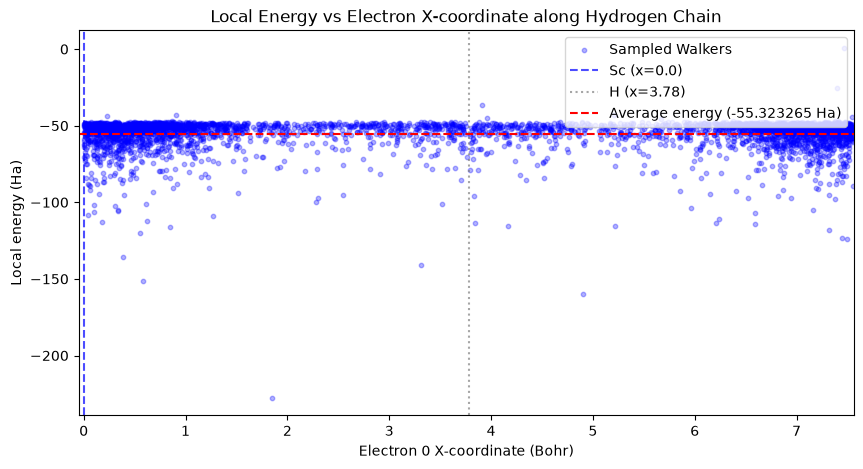

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data the GPU calculated for you
arrays_cache_file = Path(
    "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/eval_results/epoch_9999_plot_arrays.npz"
)
cached_data = np.load(arrays_cache_file)

local_energies = cached_data["local_energies"]
x_coords = cached_data["x_coords"]

# 2. Instantly generate the plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    x_coords, local_energies, alpha=0.3, s=10, color="blue", label="Sampled Walkers"
)

ax.axvline(x=0.0, color="blue", linestyle="--", alpha=0.7, label="Sc (x=0.0)")
ax.axvline(x=3.78, color="gray", linestyle=":", alpha=0.7, label="H (x=3.78)")
ax.axhline(
    y=-55.323265, color="r", linestyle="--", label="Average energy (-55.323265 Ha)"
)

ax.set_xlabel("Electron 0 X-coordinate (Bohr)")
ax.set_ylabel("Local energy (Ha)")
ax.set_title("Local Energy vs Electron X-coordinate along Hydrogen Chain")
ax.set_xlim(-0.05, 7.56)


ax.legend(loc="upper right")
plt.show()

In [6]:
np.load(arrays_cache_file)

NpzFile '/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/sc_h_chain_3.78_spin_6_6/eval_results/epoch_9999_plot_arrays.npz' with keys: local_energies, x_coords